# **Veri Yükleme ve Ağaç İçin Ön İşleme**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# 1. Veri Setini Yükle
df = pd.read_csv("/content/Customer behaviour Tourism.csv")
df = df.drop('UserID', axis=1, errors='ignore')

# 2. Eksik Verileri Doldur
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Target (Hedef) ve Özellik (X) Ayrımı
le = LabelEncoder()
df['Taken_product'] = le.fit_transform(df['Taken_product']) # Yes: 1, No: 0

X = df.drop('Taken_product', axis=1)
y = df['Taken_product']

# 4. Kategorik Değişkenleri Sayısallaştırma
X = pd.get_dummies(X, drop_first=True)

# 5. Train/Test Bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("="*50)
print("🛫 TURİZM MÜŞTERİ VERİSİ HAZIR!")
print("="*50)
print(f"Toplam Müşteri: {len(df)}")
print(f"Modelde Kullanılacak Özellik Sayısı: {X.shape[1]}")
print(f"Hedef Sınıflar: 0 (Almadı), 1 (Satın Aldı)")

🛫 TURİZM MÜŞTERİ VERİSİ HAZIR!
Toplam Müşteri: 11760
Modelde Kullanılacak Özellik Sayısı: 73
Hedef Sınıflar: 0 (Almadı), 1 (Satın Aldı)


# **Karar Ağacını Eğitme ve Başarı Raporu**

🌳 DECISION TREE EĞİTİMİ VE SONUÇLAR
Test Doğruluğu (Accuracy): % 85.97

                precision    recall  f1-score   support

    Almadı (0)       0.88      0.97      0.92      1973
Satın Aldı (1)       0.64      0.30      0.40       379

      accuracy                           0.86      2352
     macro avg       0.76      0.63      0.66      2352
  weighted avg       0.84      0.86      0.84      2352



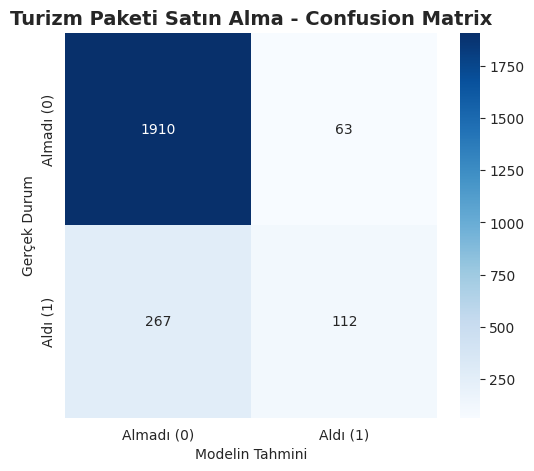

In [3]:
print("="*50)
print("🌳 DECISION TREE EĞİTİMİ VE SONUÇLAR")
print("="*50)

# Ağacın okunabilir olması ve aşırı öğrenmemesi için max_depth=4 yapıyoruz
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini', min_samples_split=10)
dt_model.fit(X_train, y_train)

# Tahmin ve Skor
y_pred = dt_model.predict(X_test)
print(f"Test Doğruluğu (Accuracy): % {accuracy_score(y_test, y_pred)*100:.2f}\n")
print(classification_report(y_test, y_pred, target_names=['Almadı (0)', 'Satın Aldı (1)']))

# Karışıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Almadı (0)', 'Aldı (1)'],
            yticklabels=['Almadı (0)', 'Aldı (1)'])
plt.title('Turizm Paketi Satın Alma - Confusion Matrix', fontweight='bold', fontsize=14)
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()

# **Karar Ağacı Kurallarını Görselleştirme (Algoritmanın Beyni)**

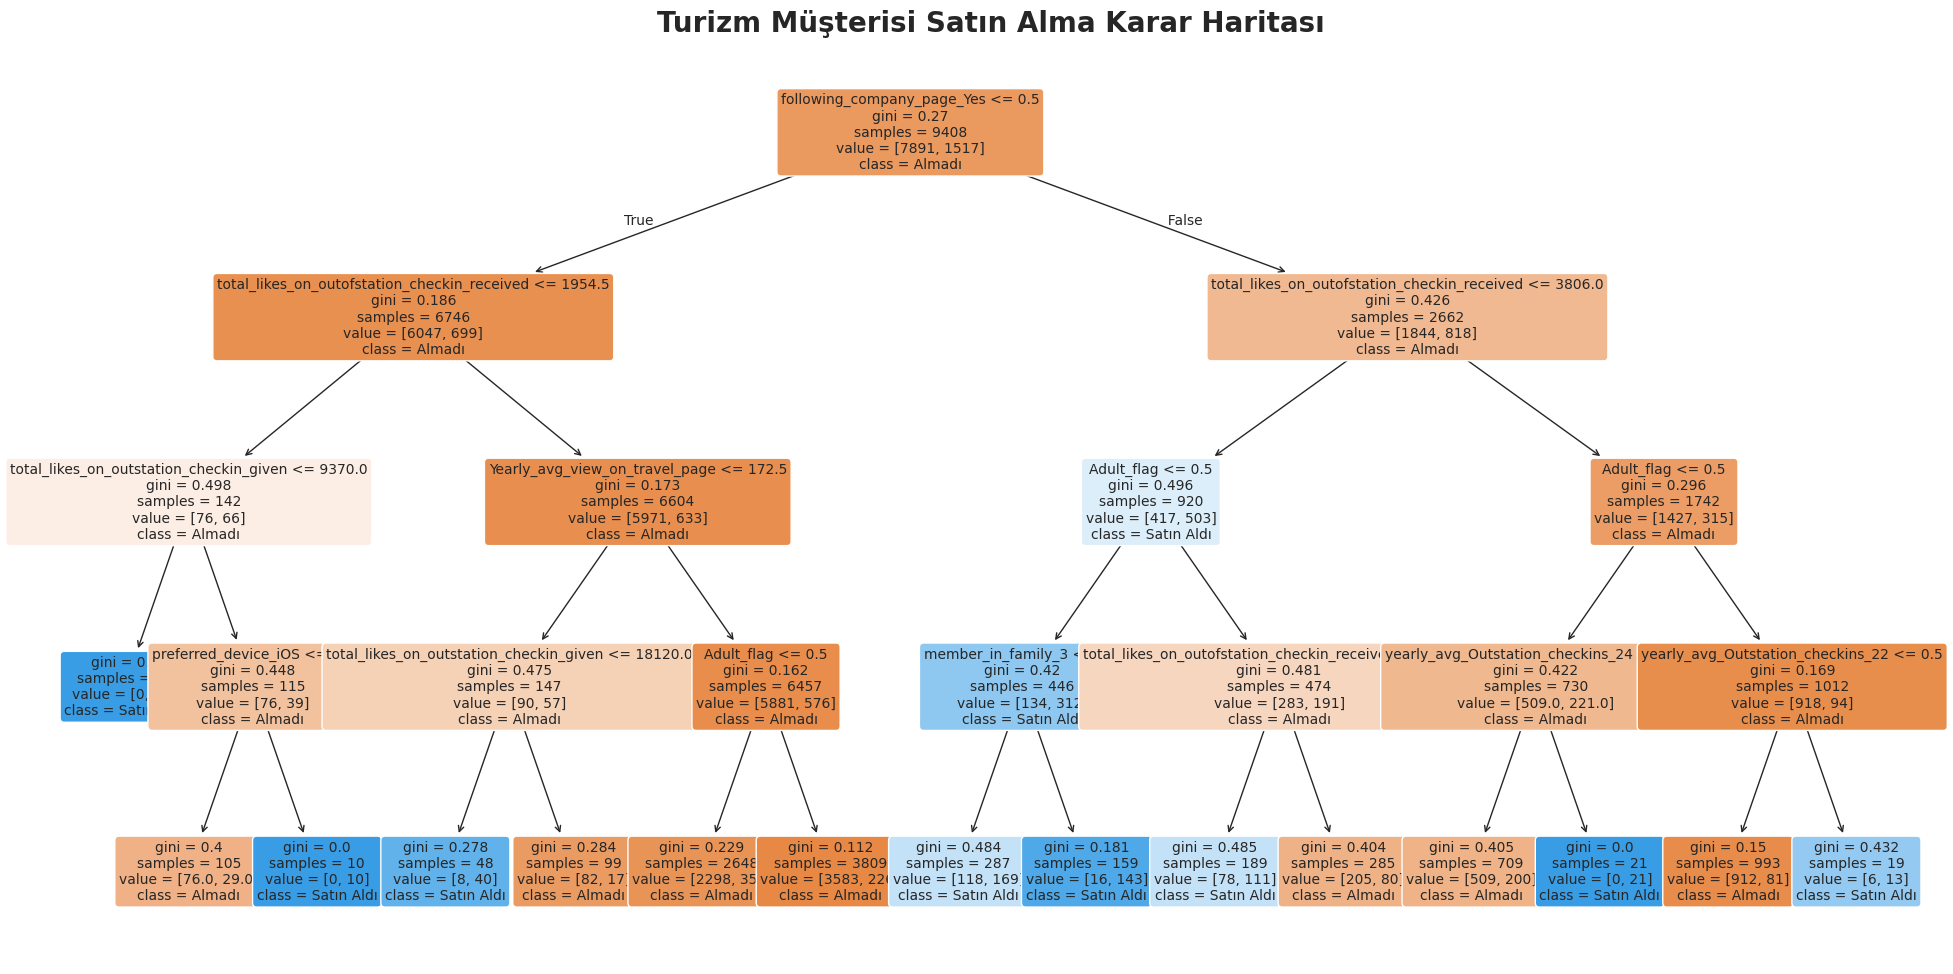


💡 HARİTA NASIL OKUNUR (Pazarlama Ekibi İçin Çıkarımlar):
• En üstteki kutuya bakın: Model müşterileri ayırmak için İLK OLARAK hangi sütuna bakmış?
• Şart sağlanıyorsa (True) Sola, sağlanmıyorsa (False) Sağa gidilir.
• Kutu rengi Turuncu ise müşteri ağırlıklı olarak 'Almadı', Mavi ise 'Satın Aldı' sınıfındadır.
• Bu harita sayesinde; 'Şu yaştaki, şu cihazı kullanan müşterilere kampanya yapalım' gibi stratejiler kurulabilir.


In [4]:
# Ağacı büyük ve detaylı çizdirelim
plt.figure(figsize=(24, 12))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Almadı', 'Satın Aldı'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=False)

plt.title('Turizm Müşterisi Satın Alma Karar Haritası', fontweight='bold', fontsize=20)
plt.show()

print("\n💡 HARİTA NASIL OKUNUR (Pazarlama Ekibi İçin Çıkarımlar):")
print("• En üstteki kutuya bakın: Model müşterileri ayırmak için İLK OLARAK hangi sütuna bakmış?")
print("• Şart sağlanıyorsa (True) Sola, sağlanmıyorsa (False) Sağa gidilir.")
print("• Kutu rengi Turuncu ise müşteri ağırlıklı olarak 'Almadı', Mavi ise 'Satın Aldı' sınıfındadır.")
print("• Bu harita sayesinde; 'Şu yaştaki, şu cihazı kullanan müşterilere kampanya yapalım' gibi stratejiler kurulabilir.")

# **Özellik Önem Sıralaması (Neden Satın Alıyorlar?)**

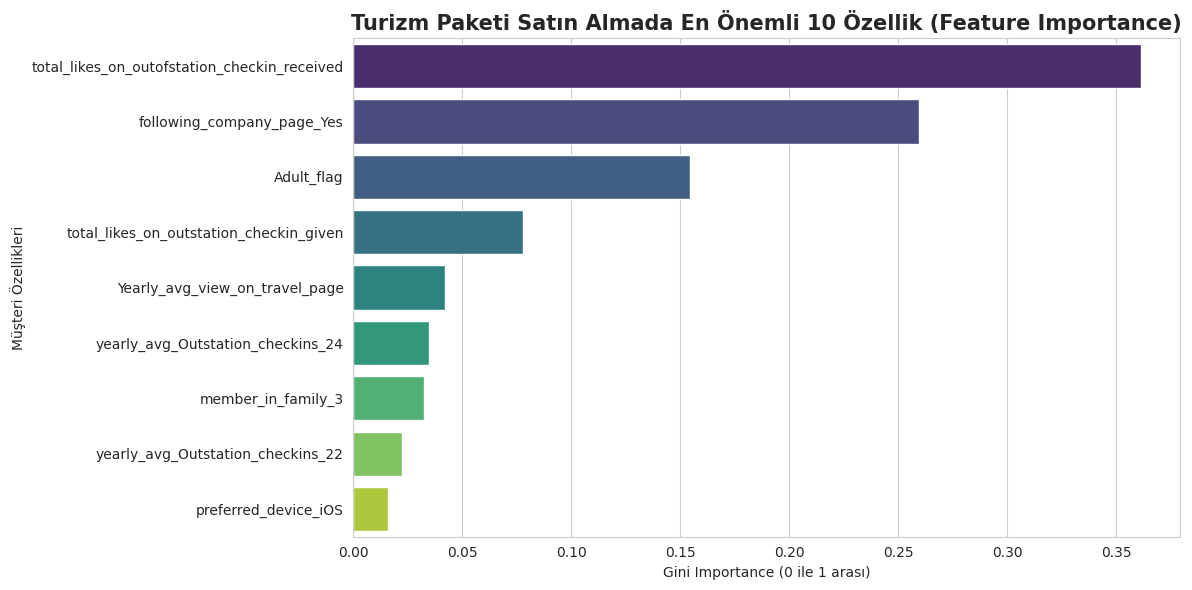


💡 YORUM:
Bu grafik, modelin hedefi tahmin ederken en çok hangi sütunlardan faydalandığını gösterir.
Pazarlama yatırımları (örneğin reklam bütçesi) en üstteki 2-3 özelliğe göre optimize edilmelidir.


In [5]:
# Müşterinin kararında en etkili özellikleri çıkaralım
onem_skorlari = dt_model.feature_importances_

df_onem = pd.DataFrame({'Özellik': X.columns, 'Önem Skoru': onem_skorlari})
df_onem = df_onem.sort_values(by='Önem Skoru', ascending=False)
df_onem = df_onem[df_onem['Önem Skoru'] > 0] # Sadece etkisi olanları al

plt.figure(figsize=(12, 6))
sns.barplot(x='Önem Skoru', y='Özellik', data=df_onem.head(10), palette='viridis')
plt.title('Turizm Paketi Satın Almada En Önemli 10 Özellik (Feature Importance)', fontweight='bold', fontsize=15)
plt.xlabel('Gini Importance (0 ile 1 arası)')
plt.ylabel('Müşteri Özellikleri')
plt.tight_layout()
plt.show()

print("\n💡 YORUM:")
print("Bu grafik, modelin hedefi tahmin ederken en çok hangi sütunlardan faydalandığını gösterir.")
print("Pazarlama yatırımları (örneğin reklam bütçesi) en üstteki 2-3 özelliğe göre optimize edilmelidir.")

In [9]:
print("="*50)
print("🔍 OVERFITTING (EZBERLEME) KONTROLÜ")
print("="*50)

# Modelin overfitting kontrolü için eğitim ve test doğruluklarını karşılaştır
train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print(f"Eğitim Seti Doğruluğu: % {train_accuracy * 100:.2f}")
print(f"Test Seti Doğruluğu:   % {test_accuracy * 100:.2f}")
print("-" * 30)

# Farkı hesapla
fark = train_accuracy - test_accuracy

if fark > 0.10:
    print(f"⚠️ DİKKAT: Model overfitting (ezberleme) yapıyor olabilir!\n(Eğitim ve Test farkı % {fark*100:.1f} > %10)")
elif fark > 0.05:
    print(f"⚠️ DİKKAT: Hafif overfitting olabilir.\n(Eğitim ve Test farkı % {fark*100:.1f} > %5)")
elif fark < -0.05:
    print(f"⚠️ DİKKAT: Underfitting (Yetersiz öğrenme) veya test setinde bir anormallik olabilir.\n(Test skoru eğitimden daha yüksek)")
else:
    print(f"✅ HARİKA: Model genellemesi çok iyi, overfitting yok!\n(Eğitim ve Test farkı sadece % {fark*100:.1f})")

🔍 OVERFITTING (EZBERLEME) KONTROLÜ
Eğitim Seti Doğruluğu: % 87.15
Test Seti Doğruluğu:   % 85.97
------------------------------
✅ HARİKA: Model genellemesi çok iyi, overfitting yok!
(Eğitim ve Test farkı sadece % 1.2)


# **Model Optimizasyonu (Aşırı Öğrenme / Overfitting Analizi)**

📈 AĞAÇ DERİNLİĞİ ve OVERFITTING (EZBERLEME) ANALİZİ


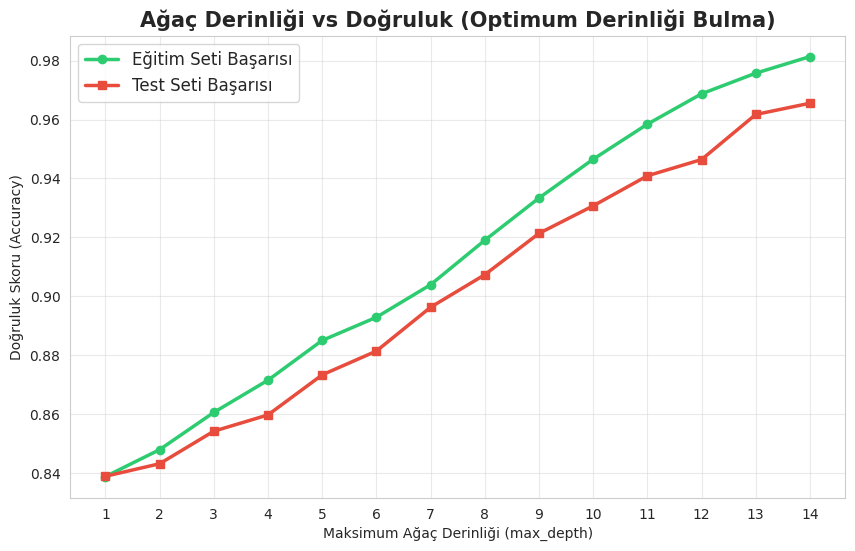


💡 YORUM:
• Eğitim skoru (Yeşil çizgi) ağaç derinleştikçe sürekli artar. Çünkü model veriyi ezberlemeye başlar.
• Test skoru (Kırmızı çizgi) ise bir noktadan sonra sabit kalır veya düşer. (İşte burası Overfitting noktasıdır!)
• Kırmızı çizginin en yüksek olduğu (veya yataya bağladığı) derinlik bizim için en iyi ve en güvenilir modeldir.


In [6]:
print("="*50)
print("📈 AĞAÇ DERİNLİĞİ ve OVERFITTING (EZBERLEME) ANALİZİ")
print("="*50)

derinlikler = range(1, 15)
egitim_skorlari = []
test_skorlari = []

for derinlik in derinlikler:
    model_test = DecisionTreeClassifier(max_depth=derinlik, random_state=42)
    model_test.fit(X_train, y_train)

    # Skorları kaydet
    egitim_skorlari.append(model_test.score(X_train, y_train))
    test_skorlari.append(model_test.score(X_test, y_test))

# Çizgi Grafiği ile karşılaştırma
plt.figure(figsize=(10, 6))
plt.plot(derinlikler, egitim_skorlari, marker='o', label='Eğitim Seti Başarısı', color='#2ecc71', linewidth=2.5)
plt.plot(derinlikler, test_skorlari, marker='s', label='Test Seti Başarısı', color='#e74c3c', linewidth=2.5)

plt.title('Ağaç Derinliği vs Doğruluk (Optimum Derinliği Bulma)', fontweight='bold', fontsize=15)
plt.xlabel('Maksimum Ağaç Derinliği (max_depth)')
plt.ylabel('Doğruluk Skoru (Accuracy)')
plt.xticks(derinlikler)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.show()

print("\n💡 YORUM:")
print("• Eğitim skoru (Yeşil çizgi) ağaç derinleştikçe sürekli artar. Çünkü model veriyi ezberlemeye başlar.")
print("• Test skoru (Kırmızı çizgi) ise bir noktadan sonra sabit kalır veya düşer. (İşte burası Overfitting noktasıdır!)")
print("• Kırmızı çizginin en yüksek olduğu (veya yataya bağladığı) derinlik bizim için en iyi ve en güvenilir modeldir.")